Importy

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import glob
import itertools
import copy
import os
import warnings

WSPÓLNE FUNKCJE I KLASY SIECI

In [2]:
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): 
        return self.net(x)

def train_greybox_model(model, dataloader, epochs=2000, patience=80, min_delta=1e-6):
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95)
    criterion = nn.L1Loss() 
    
    best_loss = float('inf') 
    patience_counter = 0     
    best_model_weights = copy.deepcopy(model.state_dict()) 
    
    model.train()
    print(f"Rozpoczynam trening (Maksymalnie {epochs} epok, Cierpliwość: {patience})...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        for u_seq, y_true_seq in dataloader:
            x_init = torch.zeros(u_seq.size(0), model.num_states)
            optimizer.zero_grad()
            y_pred_seq = model(u_seq, x_init)
            loss = criterion(y_pred_seq.view_as(y_true_seq), y_true_seq)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1:04d}/{epochs} | Strata MAE: {avg_loss:.6f}")
            
        # Early Stopping
        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss               
            patience_counter = 0               
            best_model_weights = copy.deepcopy(model.state_dict()) 
        else:
            patience_counter += 1              
            
        if patience_counter >= patience:
            print(f"\n[!] EARLY STOPPING: Przerwano trening w epoce {epoch+1}!")
            print(f"Brak poprawy o minimum {min_delta} od {patience} epok.")
            break 
            
    model.load_state_dict(best_model_weights)
    print(f"Trening zakończony. Załadowano najlepsze wagi ze stratą MSE: {best_loss:.6f}\n")
    return model

def create_sequences(inputs, targets, seq_len=600):
    xs, ys = [], []
    for i in range(0, len(inputs) - seq_len + 1, seq_len):
        xs.append(inputs[i : i + seq_len])
        ys.append(targets[i : i + seq_len])
    return np.array(xs), np.array(ys)


def validate_and_plot(model, scaler_u, scaler_y, input_cols, target_cols, file_path, title_prefix, alpha=0.05, threshold=None, burn_in=0):
    df_test = pd.read_csv(file_path)
    
    # Upewniamy się, że kolumna z cechą inżynierską istnieje w danych testowych
    if 'delta_pressure' not in df_test.columns:
        df_test['delta_pressure'] = np.sqrt(np.abs(df_test['intake_manifold_pressure'] - df_test['Intercooler_pressure']))
        
    X_test_tensor = torch.tensor(scaler_u.transform(df_test[input_cols].values), dtype=torch.float32).unsqueeze(0)
    Y_test_tensor = torch.tensor(scaler_y.transform(df_test[target_cols].values), dtype=torch.float32).unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor, torch.zeros(1, model.num_states))
        
    y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
    y_true_real = scaler_y.inverse_transform(Y_test_tensor[0].cpu().numpy().reshape(-1, 1))
    czas = np.arange(len(y_true_real)) * 0.05
    
    # --- NAPRAWA LOGIKI FILTRA ---
    e_raw = np.abs(y_true_real - y_pred_real).flatten()
    e_filtered = np.zeros_like(e_raw) 
    
    # Burn-in zastosowany PRZED pętlą filtrującą
    if burn_in > 0:
        e_raw[:burn_in] = 0.0
        
    e_filtered[0] = e_raw[0] 
    for i in range(1, len(e_raw)):
        e_filtered[i] = alpha * e_raw[i] + (1 - alpha) * e_filtered[i-1]
        
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    ax1.plot(czas, y_true_real, label='Prawda (Czujnik)', color='black', alpha=0.7)
    ax1.plot(czas, y_pred_real, label='Symulacja (AI)', color='red', linestyle='--', alpha=0.9)
    ax1.set_title(f'{title_prefix} | Plik: {os.path.basename(file_path)}', fontsize=12)
    ax1.set_ylabel('Wartość fizyczna')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    ax2.plot(czas, e_raw, label='Surowe Reziduum (Szum)', color='gray', alpha=0.4)
    ax2.plot(czas, e_filtered, label=f'Przefiltrowane Reziduum (alpha={alpha})', color='darkred', linewidth=2)
    
    if threshold is not None:
        ax2.axhline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Próg Detekcji ({threshold})')
        
    ax2.set_title('Sygnał Diagnostyczny (Reziduum)', fontsize=12)
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd predykcji')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Średni błąd bezwzględny (MAE po rozgrzewce): {np.mean(e_raw[burn_in:]):.4f}")
    print(f"Maksymalny błąd przefiltrowany (po rozgrzewce): {np.max(e_filtered[burn_in:]):.4f}")

MSO_10 - równanie ciągłości

In [3]:
class GreyBoxSystem_MSO10(nn.Module):
    # NAPRAWA WYMIARÓW: Dodałem parametr num_inputs, aby wymiary zgadzały się z danymi!
    def __init__(self, T_sample=0.05, num_states=1, num_inputs=3):
        super(GreyBoxSystem_MSO10, self).__init__()
        self.T = T_sample
        self.num_states = num_states
        self.num_inputs = num_inputs
        
        total_feat = self.num_states + self.num_inputs
        self.g_func = SubNetwork(total_feat, 1)
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)


# ==========================================
# GŁÓWNA PĘTLA WYKONAWCZA (DATA PREP & TRAIN)
# ==========================================
if __name__ == "__main__":
    
    DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"

    HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
    FAULTY_FILES_IML = glob.glob(os.path.join(DATA_DIR, "*_f_iml*.csv"))

    healthy_dfs = [pd.read_csv(f) for f in HEALTHY_FILES]
    faulty_dfs = [pd.read_csv(f) for f in FAULTY_FILES_IML]

    # Bezpiecznik: Upewniamy się, że załadowaliśmy jakiekolwiek pliki
    if not healthy_dfs and not faulty_dfs:
        print(f"BŁĄD: Nie znaleziono plików CSV w katalogu {DATA_DIR}!")
    else:
        df_train = pd.concat(healthy_dfs + faulty_dfs, ignore_index=True)

        # NAPRAWA FEATURE ENGINEERING: Tworzymy nową kolumnę w DataFrame
        df_train['delta_pressure'] = np.sqrt(np.abs(df_train['intake_manifold_pressure'] - df_train['Intercooler_pressure']))

        u_cols_10 = ['delta_pressure', 'air_mass_flow', 'throttle_position']
        y_cols_10 = ['injected_fuel_mass']

        scaler_u10, scaler_y10 = MinMaxScaler(), MinMaxScaler()
        u10_norm = scaler_u10.fit_transform(df_train[u_cols_10].values)
        y10_norm = scaler_y10.fit_transform(df_train[y_cols_10].values)

        X_seq10, Y_seq10 = create_sequences(u10_norm, y10_norm)
        loader10 = DataLoader(TensorDataset(torch.tensor(X_seq10, dtype=torch.float32), 
                                            torch.tensor(Y_seq10, dtype=torch.float32)), 
                              batch_size=16, shuffle=True)

        # NAPRAWA NAZEWNICTWA I INICJALIZACJI:
        # Przekazujemy num_inputs=2 (zgodnie z u_cols_10) do klasy modelu
        model_10 = GreyBoxSystem_MSO10(T_sample=0.05, num_states=1, num_inputs=len(u_cols_10))
        
        # Uruchamiamy trening
        #model_10 = train_greybox_model(model_10, loader10, epochs=2000)

        # Zapisujemy pod właściwą, niezdezorientowaną nazwą
        #torch.save(model_10.state_dict(), 'szara_skrzynka_mso10_throttle.pth')
        #joblib.dump(scaler_u10, 'scaler_u_mso10_throttle.pkl')
        #joblib.dump(scaler_y10, 'scaler_y_mso10_throttle.pkl')

        print("Model MSO 10 wytrenowany i poprawnie zapisany!")

Model MSO 10 wytrenowany i poprawnie zapisany!


Walidacja

Model MSO 10 i skalery zostały pomyślnie wczytane z dysku!


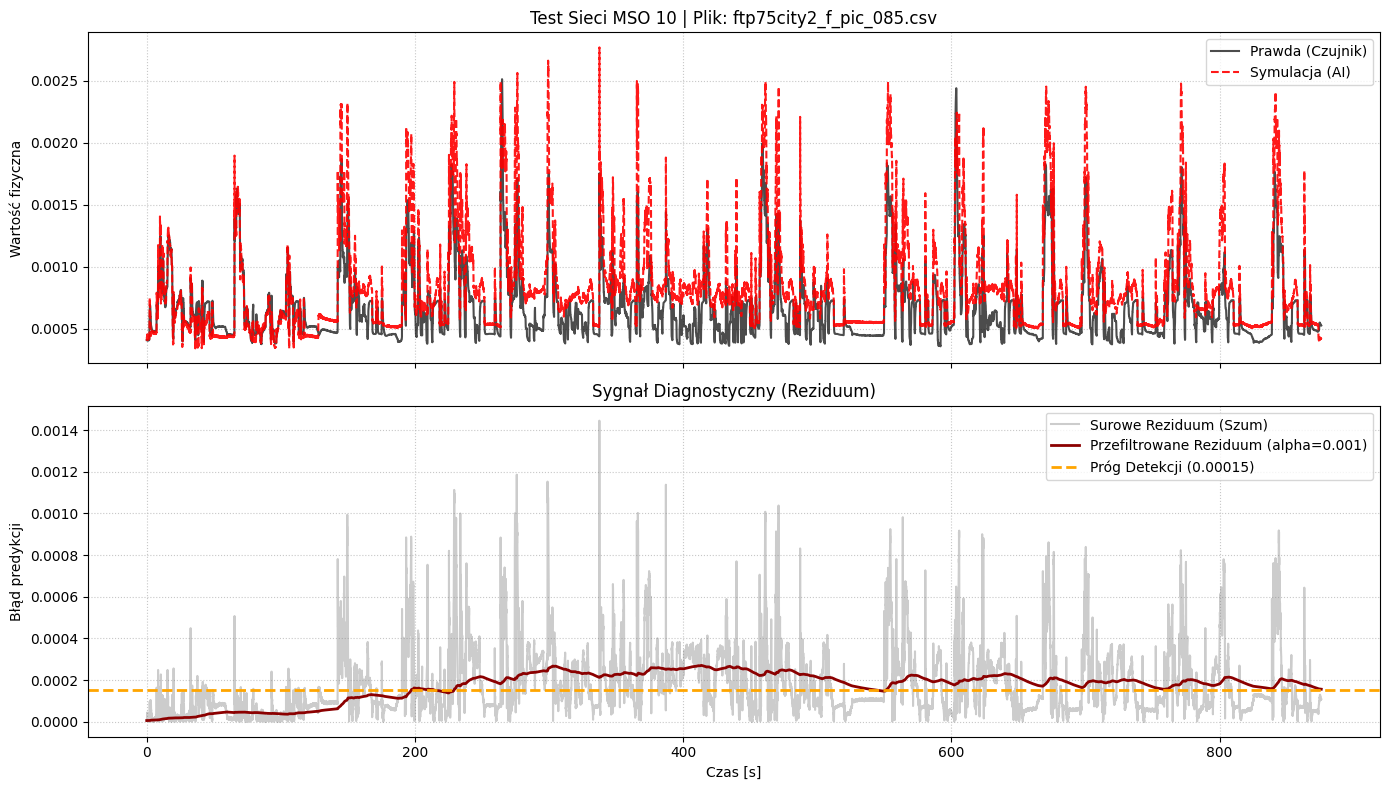

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0003


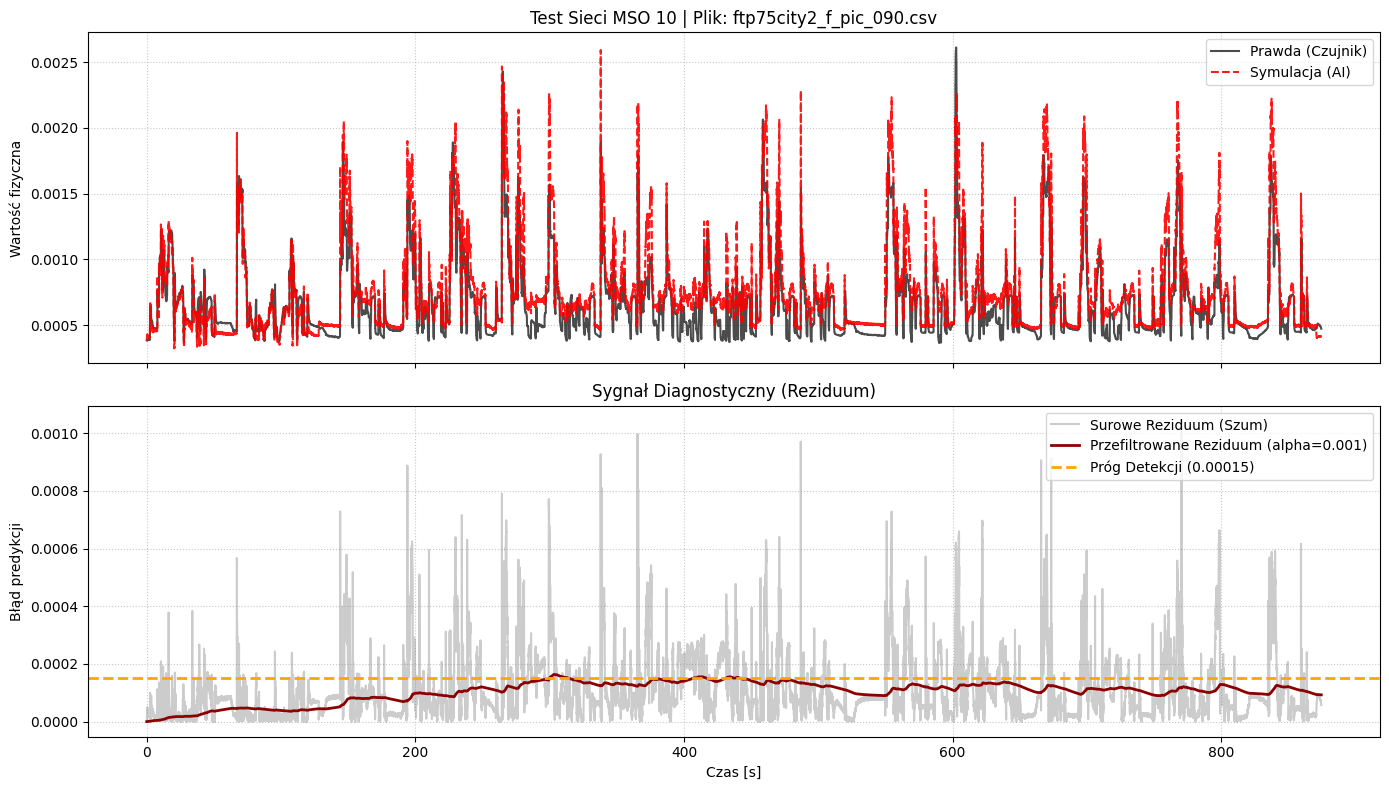

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


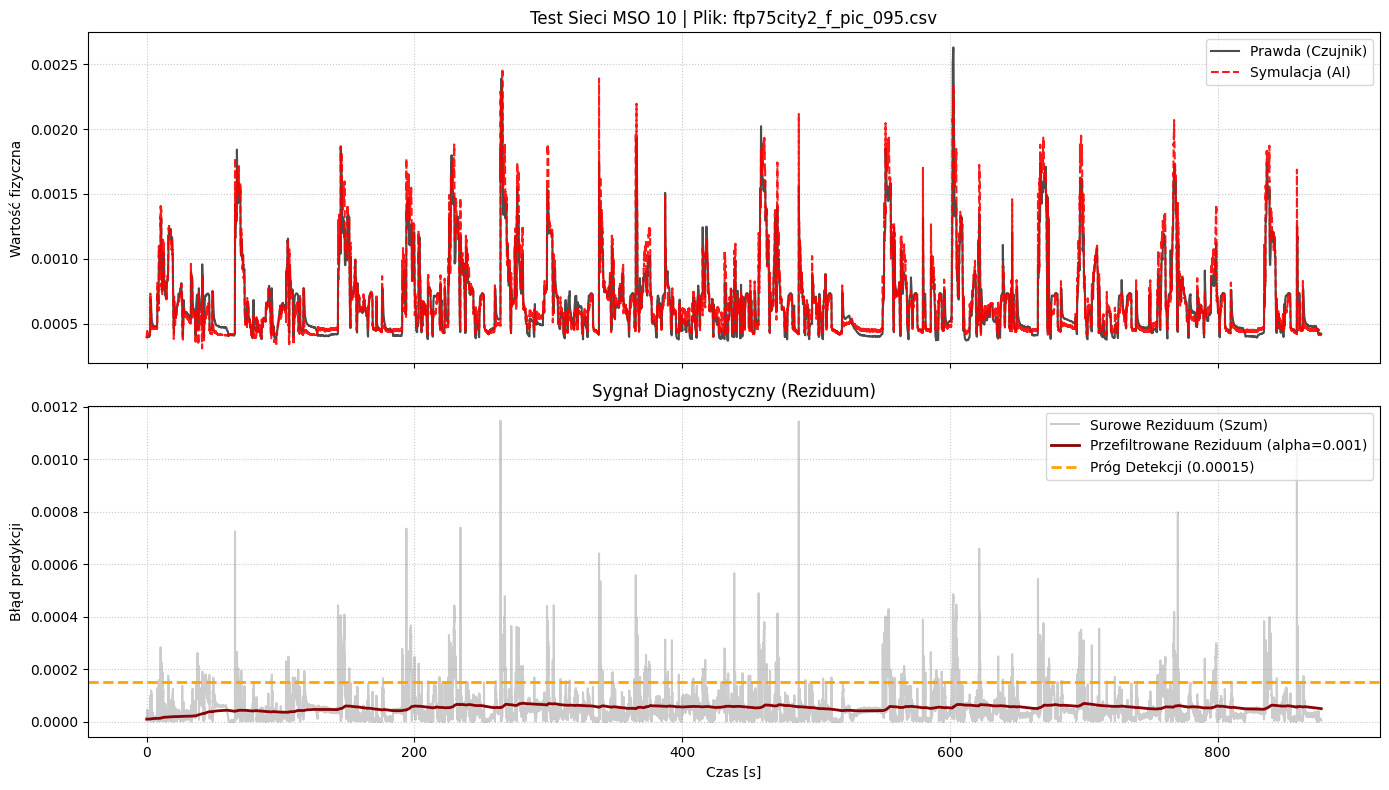

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


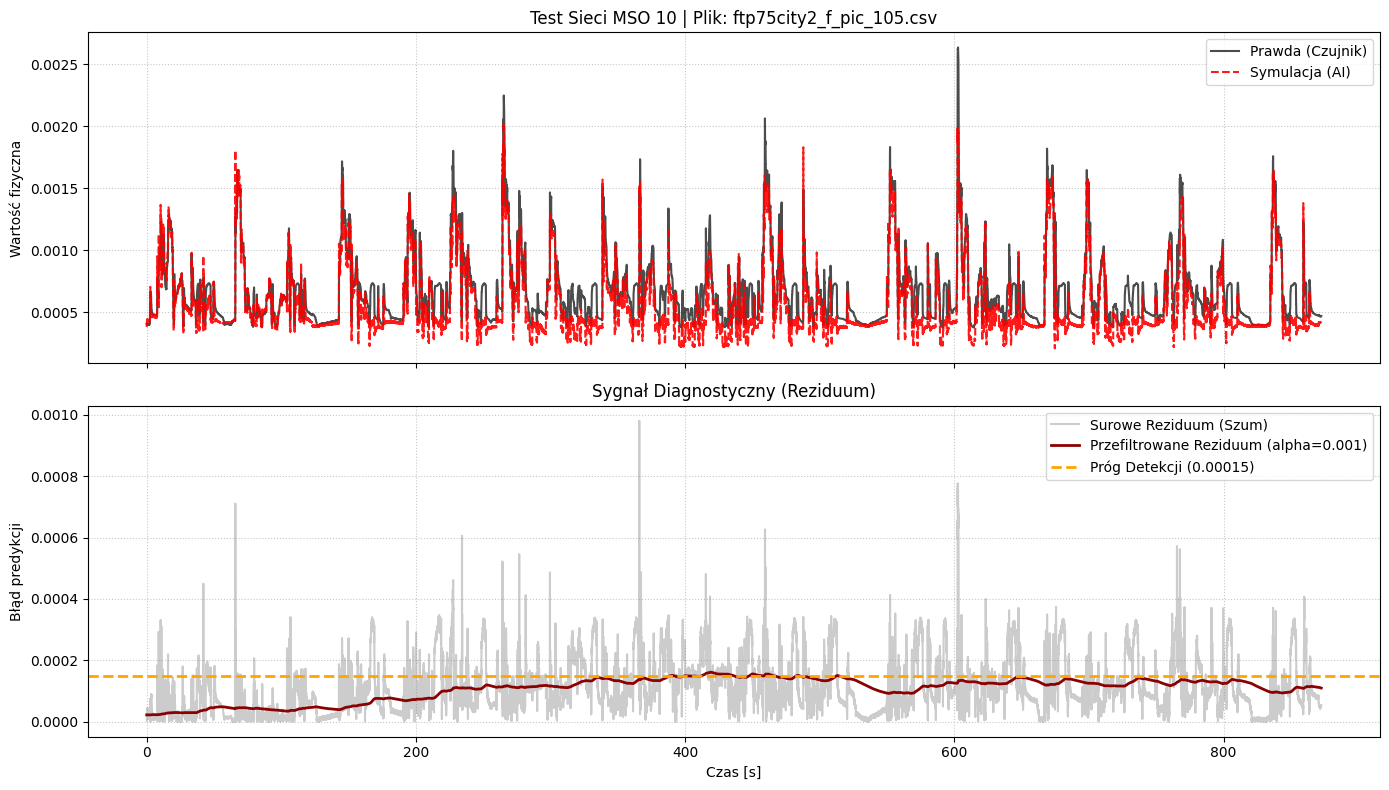

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


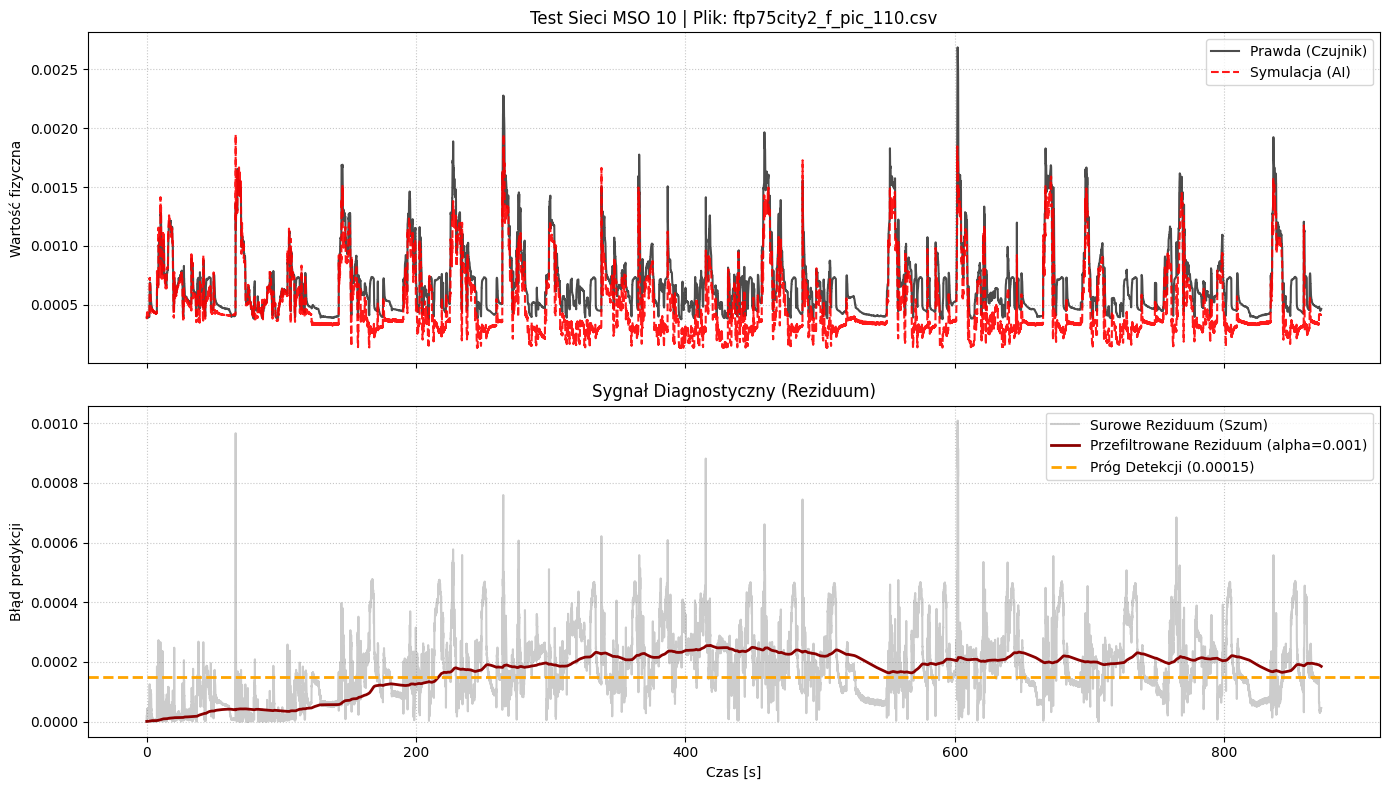

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0003


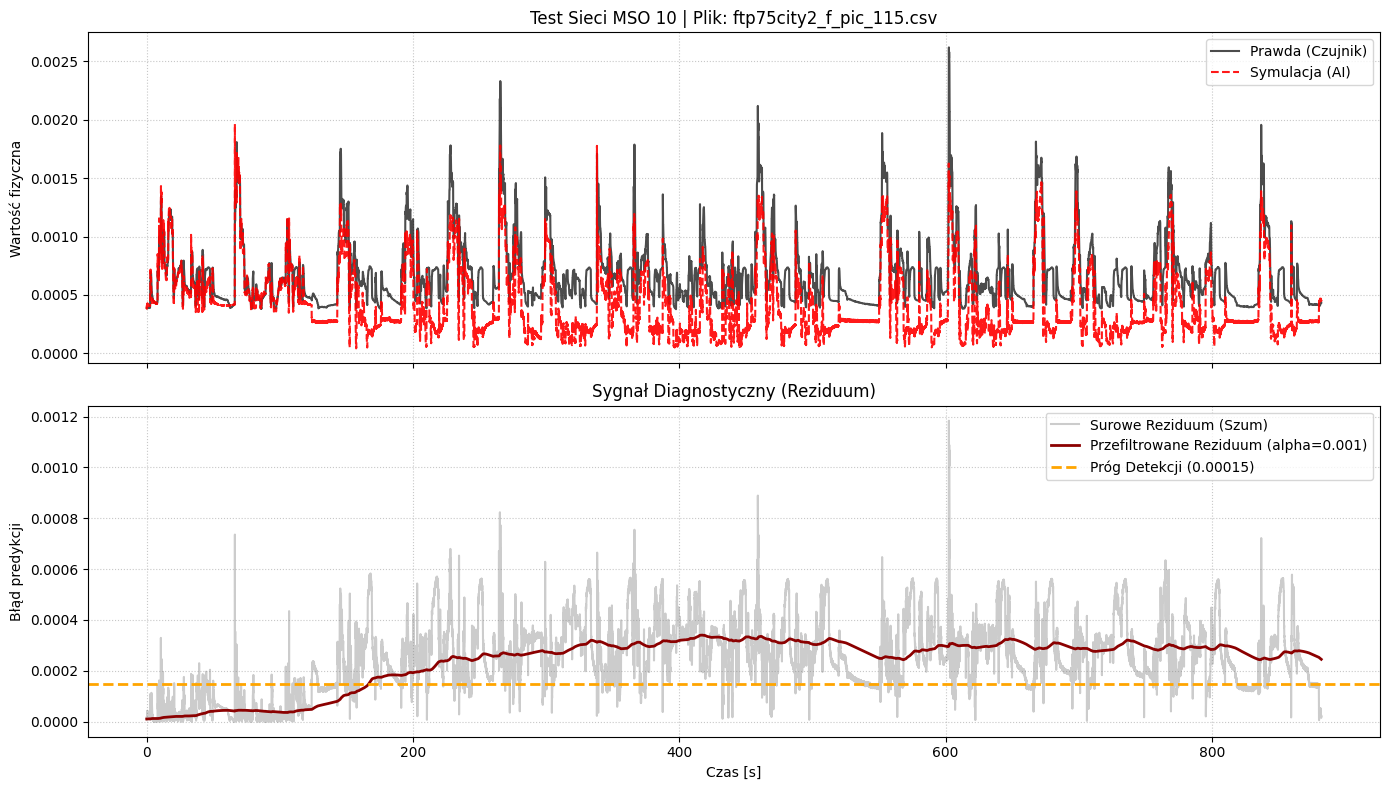

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0003
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0003


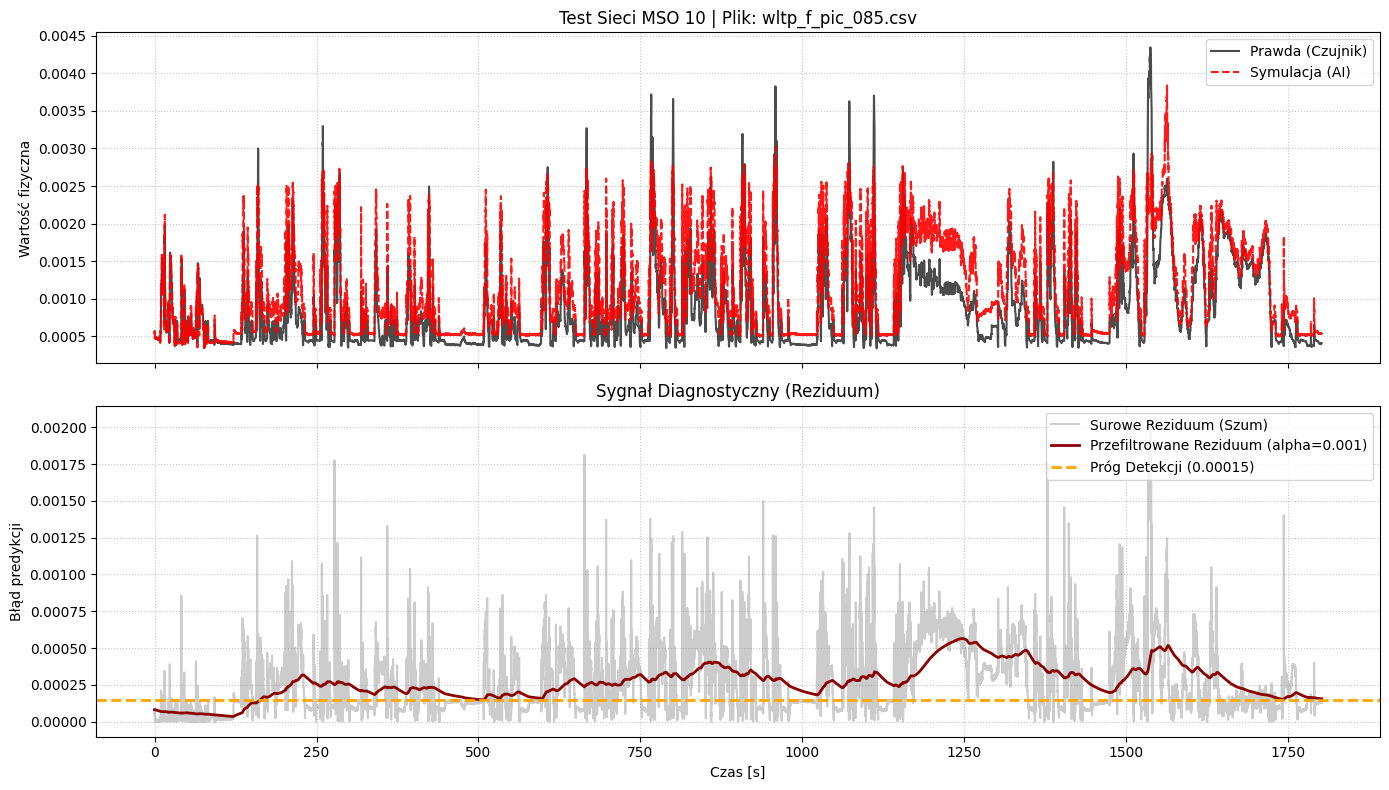

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0003
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0006


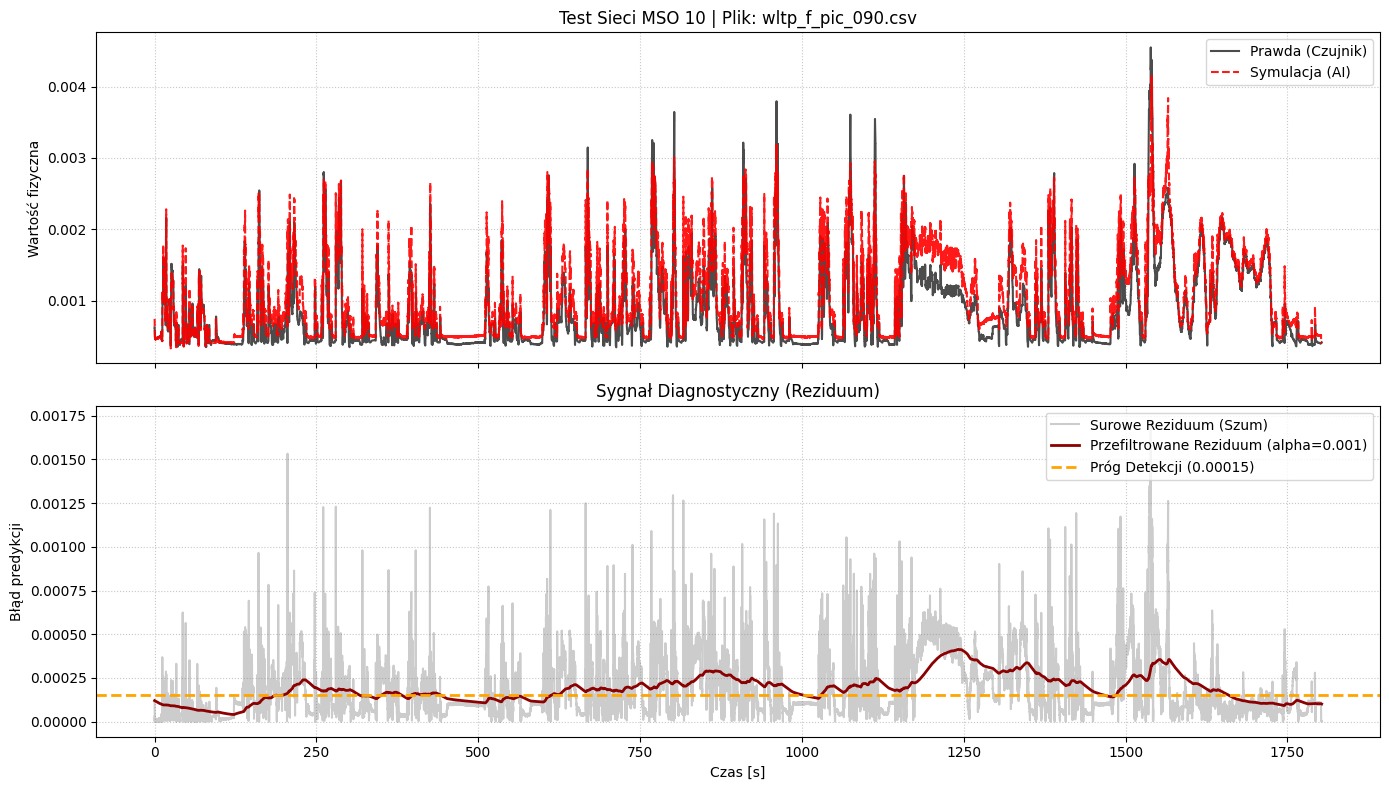

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0004


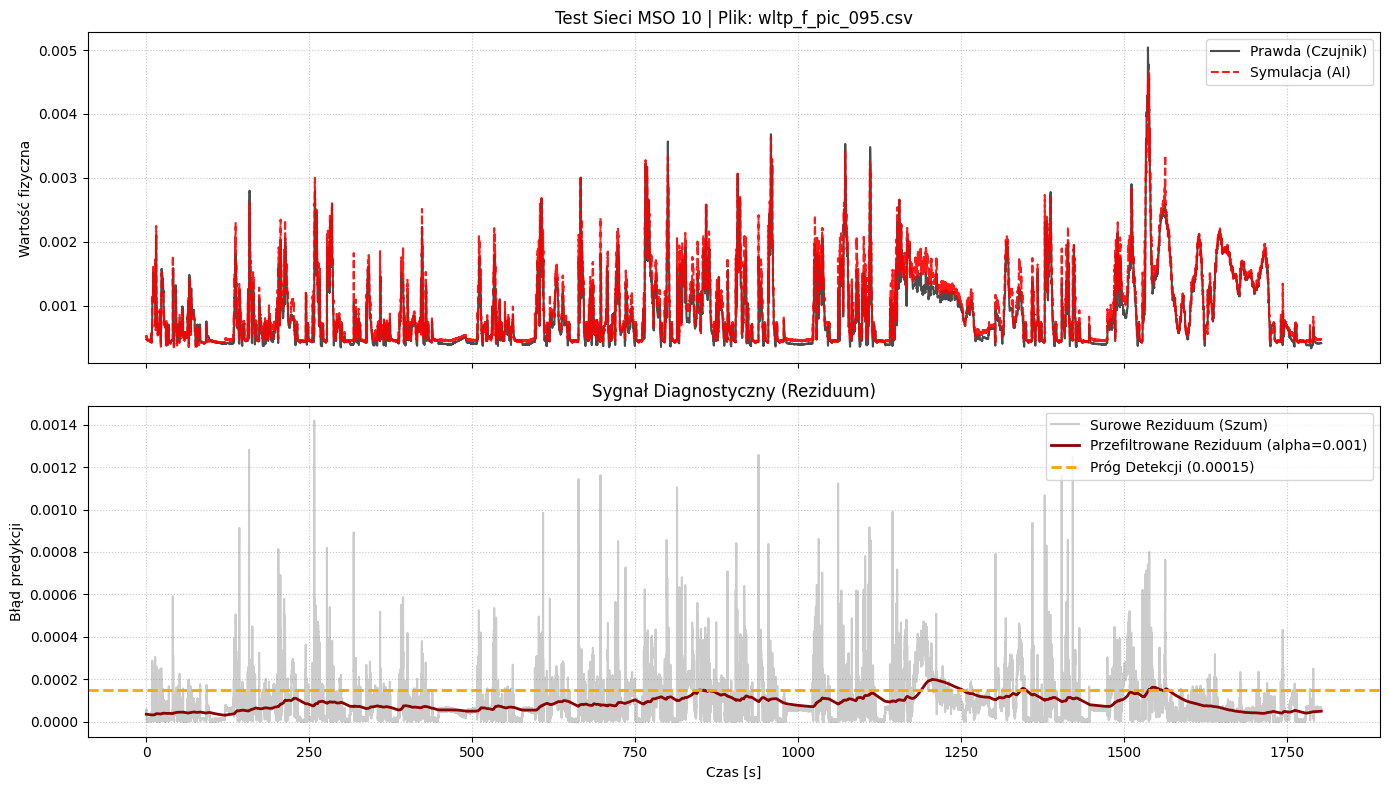

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


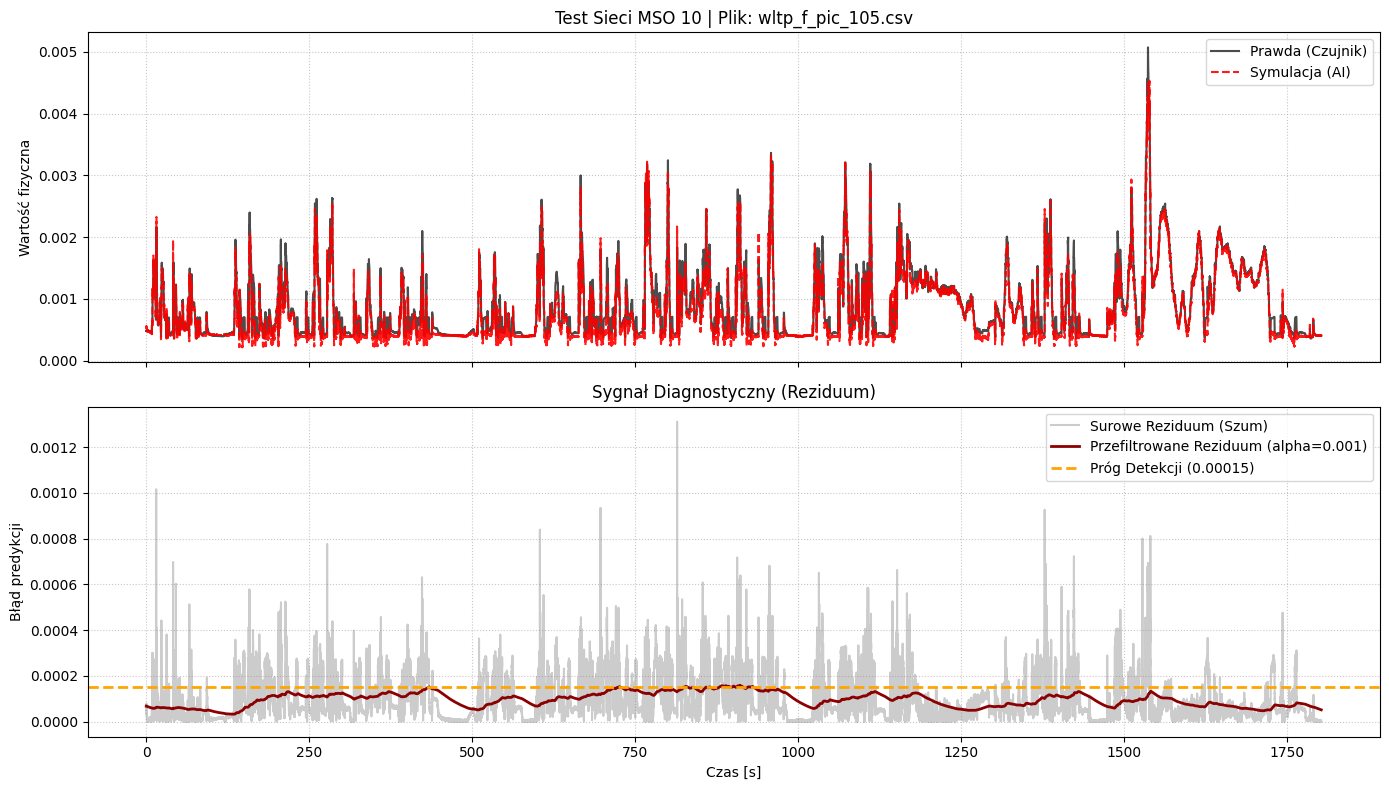

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


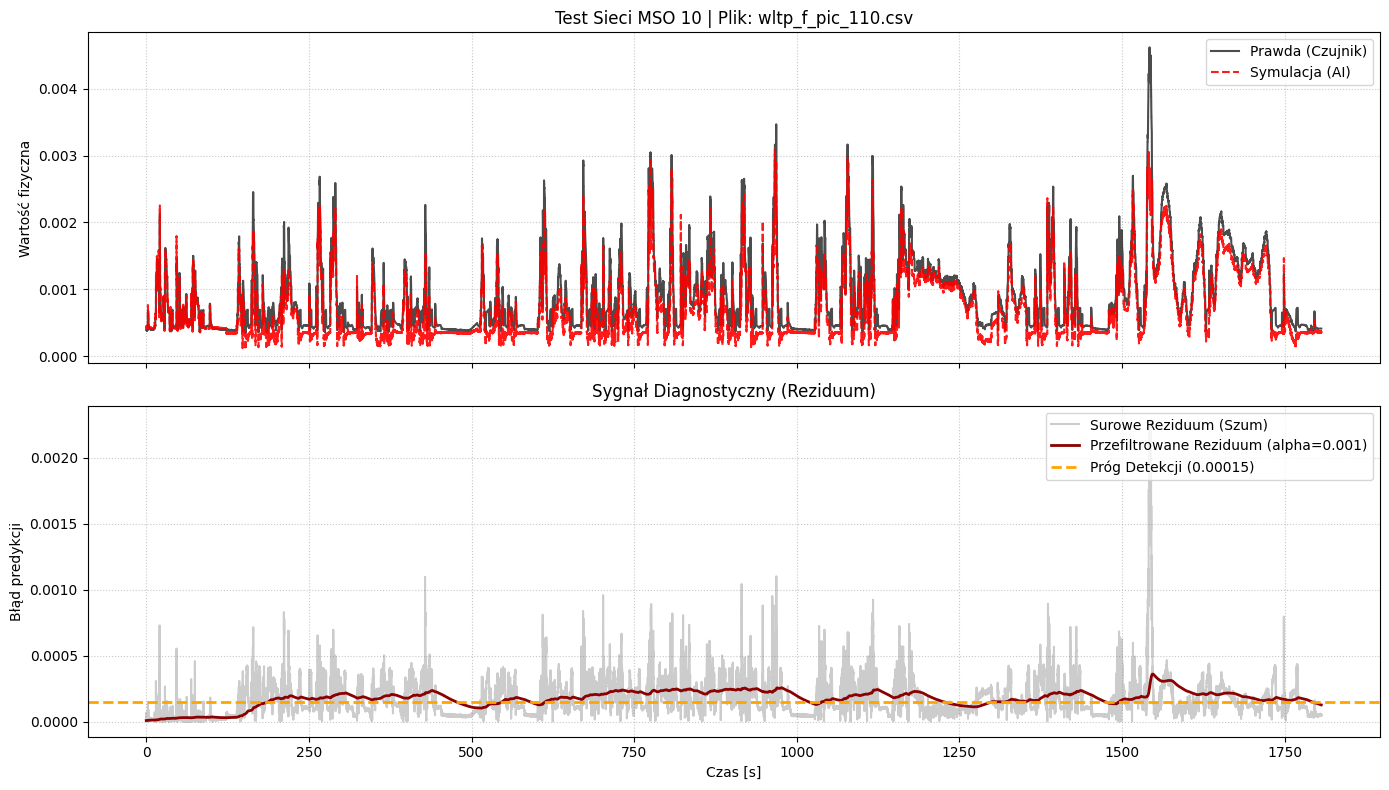

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0004


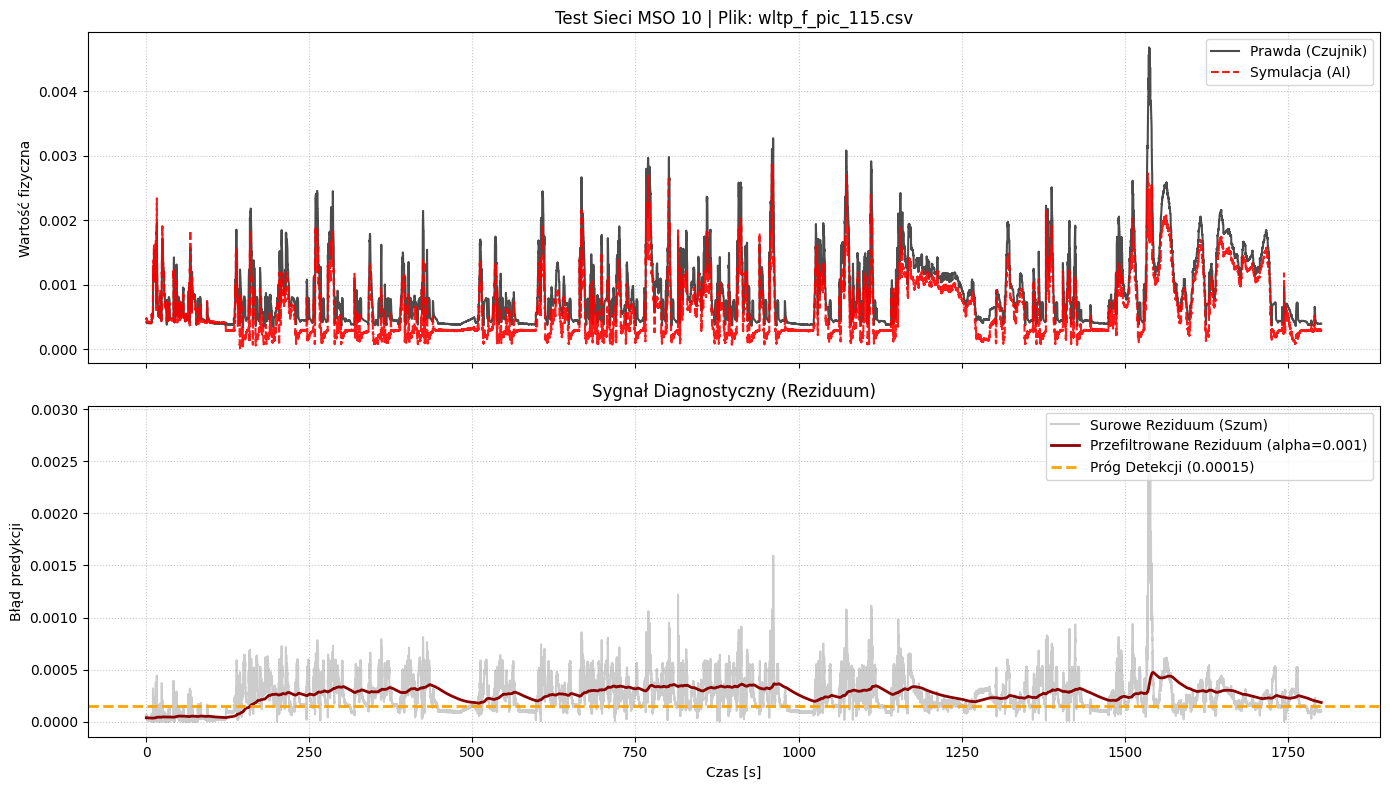

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0003
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0005


In [6]:
model10 = GreyBoxSystem_MSO10(T_sample=0.05, num_states=1, num_inputs=3) # Pamiętaj o wymiarach!

# 3. Wczytanie MÓZGU (wytrenowanych wag) i SKALERÓW z dysku
model10.load_state_dict(torch.load('szara_skrzynka_mso10_throttle.pth'))
model10.eval() # Ustawienie modelu w tryb predykcji
scaler_u10 = joblib.load('scaler_u_mso10_throttle.pkl')
scaler_y10 = joblib.load('scaler_y_mso10_throttle.pkl')

print("Model MSO 10 i skalery zostały pomyślnie wczytane z dysku!")

# Zbieramy ŚCIEŻKI do plików
TEST_FILES_PIC = glob.glob(os.path.join(DATA_DIR, "*_f_pic*.csv"))
TEST_FILES_PIM = glob.glob(os.path.join(DATA_DIR, "*_f_pim*.csv"))
TEST_FILES_WAF = glob.glob(os.path.join(DATA_DIR, "*_f_waf*.csv"))

# Zamiast wczytywać je tu przez pd.read_csv, robimy po prostu listę ścieżek
pliki_testowe_sciezki = [TEST_FILES_PIC]

for lista_sciezek in pliki_testowe_sciezki:
   for sciezka_do_pliku in lista_sciezek:
       # validate_and_plot samo wczyta plik w pierwszej linijce używając pd.read_csv()
       validate_and_plot(model10, scaler_u10, scaler_y10, u_cols_10, y_cols_10, 
                         sciezka_do_pliku, "Test Sieci MSO 10", 
                         alpha=0.001, threshold=0.00015)

Tutaj nie powinno być detekcji

In [ ]:
#for file in FAULTY_FILES_WAF:
    #validate_and_plot(model0, scaler_u0, scaler_y0, u_cols_0, y_cols_0, file, "Test Sieci MSO 0 (Kolektor)", alpha=0.001, threshold=2100.0)

Fine tuning

In [9]:
czestotliwosc_Hz = 20
czas_zdrowy_s = 110
limit_probek = czas_zdrowy_s * czestotliwosc_Hz
burn_in = 100 

alpha = 0.001 

wszystkie_rezidua_przefiltrowane = []
wszystkie_rezidua_surowe_bias = []

print("Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...")
model10.eval()

with torch.no_grad():
    for plik in pliki_do_walidacji:
        df = pd.read_csv(plik)
        # 1. NAPRAWA OSTRZEŻENIA .COPY()
        df_zdrowe = df.iloc[:limit_probek].copy()
        df_zdrowe['delta_pressure'] = np.sqrt(np.abs(df_zdrowe['intake_manifold_pressure'] - df_zdrowe['Intercooler_pressure']))
        
        X_tensor = torch.tensor(scaler_u10.transform(df_zdrowe[u_cols_10].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y10.transform(df_zdrowe[y_cols_10].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model10.num_states)
        y_pred = model10(X_tensor, x_init)
        
        y_pred_real = scaler_y10.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y10.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_raw_znak = (y_true_real - y_pred_real).flatten()
        
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
        
        wszystkie_rezidua_przefiltrowane.extend(e_filtered[burn_in:])
        wszystkie_rezidua_surowe_bias.extend(e_raw_znak[burn_in:])

wszystkie_rezidua_przefiltrowane = np.array(wszystkie_rezidua_przefiltrowane)
wszystkie_rezidua_surowe_bias = np.array(wszystkie_rezidua_surowe_bias)

srednia_filt = np.mean(wszystkie_rezidua_przefiltrowane)
std_filt = np.std(wszystkie_rezidua_przefiltrowane)
bias_modelu = np.mean(wszystkie_rezidua_surowe_bias)

print(f"\n{'='*50}")
print(f"WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 10) - Z FILTREM (alpha={alpha})")
print(f"{'='*50}")
# 2. NAPRAWA PRECYZJI WYŚWIETLANIA (zamiast .2f dajemy format naukowy .6f)
print(f"Średni uchyb (wygładzony)     : {srednia_filt:.6f} [Jednostka modelu np. kg]")
print(f"Odchylenie standardowe (sigma): {std_filt:.6f} [Jednostka modelu np. kg]")
print(f"Błąd systematyczny (Bias)     : {bias_modelu:.6f} [Jednostka modelu np. kg]")
print(f"-"*50)

prog_3sigma = srednia_filt + (3 * std_filt)
prog_6sigma = srednia_filt + (6 * std_filt)

print(f"💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:")
print(f"-> Bezpieczny próg (3 sigma) to {prog_3sigma:.6f}")
print(f"-> Bardzo ostrożny próg (6 sigma) to {prog_6sigma:.6f}")

Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...

WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 10) - Z FILTREM (alpha=0.001)
Średni uchyb (wygładzony)     : 0.000051 [Jednostka modelu np. kg]
Odchylenie standardowe (sigma): 0.000024 [Jednostka modelu np. kg]
Błąd systematyczny (Bias)     : 0.000021 [Jednostka modelu np. kg]
--------------------------------------------------
💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:
-> Bezpieczny próg (3 sigma) to 0.000124
-> Bardzo ostrożny próg (6 sigma) to 0.000197
